In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
dataset=pd.read_csv('height-weight.csv')

In [4]:
dataset.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


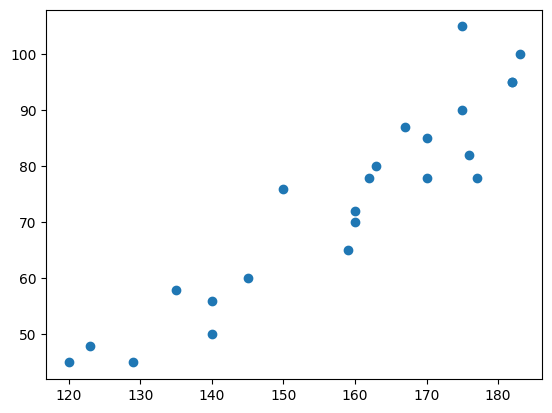

In [5]:
plt.scatter(dataset['Height'],dataset['Weight'])

In [6]:
X=dataset[['Weight']]#Independent variable
Y=dataset['Height']#Dependent variable

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
Xtrain,Xtest,Ytrain,Ytest=train_test_split(X,Y,test_size=0.2,random_state=42)    

In [9]:
X.shape

(23, 1)

In [10]:
Xtrain.shape

(18, 1)

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
scaler=StandardScaler() 

In [13]:
Xtrain=scaler.fit_transform(Xtrain)
Xtest=scaler.transform(Xtest)

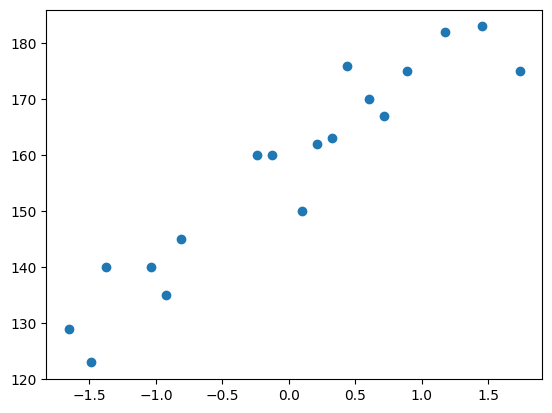

In [14]:
plt.scatter(Xtrain,Ytrain)

In [15]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [17]:

regression.fit(Xtrain,Ytrain)

print("the slope",regression.coef_)
print("the intercept",regression.intercept_)

the slope [17.03440872]
the intercept 157.5


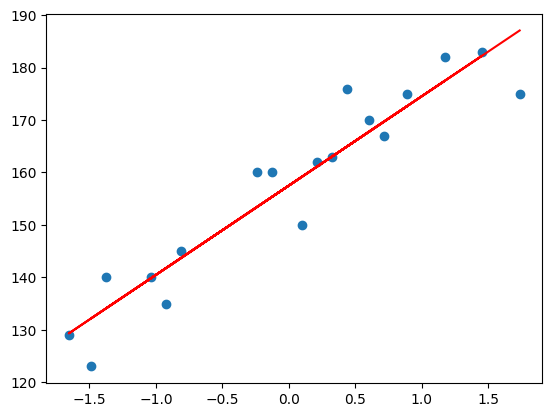

In [18]:
plt.scatter(Xtrain,Ytrain)
plt.plot(Xtrain,regression.predict(Xtrain),color='red')

In [21]:
from sklearn.metrics import mean_squared_error,r2_score
Ypred=regression.predict(Xtest)
print("Mean Squared Error:",mean_squared_error(Ytest,Ypred))
print("R-squared:",r2_score(Ytest,Ypred))

Mean Squared Error: 109.77592599051664
R-squared: 0.776986986042344


In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline


In [3]:
california=fetch_california_housing()

In [4]:
dataset=pd.DataFrame(california.data,columns=california.feature_names)

In [5]:
dataset['Price']=california.target

In [6]:
dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [8]:
import seaborn as sea


<Axes: >

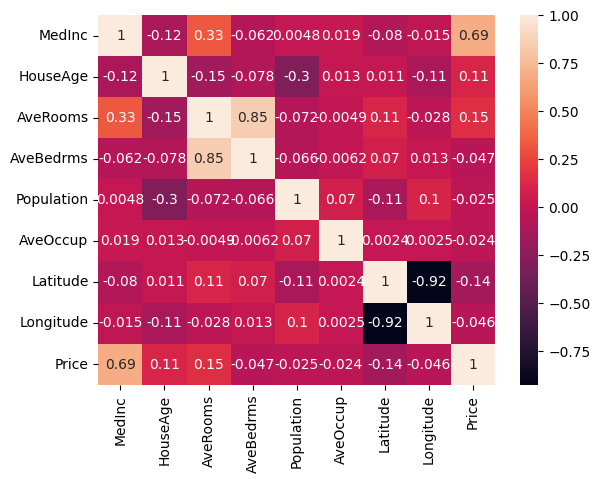

In [9]:
sea.heatmap(dataset.corr(),annot=True)

In [10]:
x=dataset.iloc[:,:-1]
y=dataset.iloc[:,-1]

In [11]:
x.head()



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [12]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64

In [13]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.33,random_state=42)

In [14]:
xtrain.shape

(13828, 8)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [17]:
xtrain=scaler.fit_transform(xtrain)

In [18]:
xtest=scaler.transform(xtest)

In [19]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [20]:
regression.fit(xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
regression.coef_

array([ 8.46603472e-01,  1.20333548e-01, -2.98800785e-01,  3.47243173e-01,
       -8.81413334e-05, -4.17242067e-02, -8.94420371e-01, -8.70401317e-01])

In [22]:
regression.intercept_

np.float64(2.0666362048018536)

In [24]:
ypred=regression.predict(xtest)

In [25]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [28]:
print(mean_squared_error(ytest,ypred))
print(r2_score(ytest,ypred))
print(mean_absolute_error(ytest,ypred))
print(np.sqrt(mean_squared_error(ytest,ypred)))

0.5369686543372459
0.5970494128783952
0.5295710106684451
0.7327814505957735


In [29]:
import pickle 
pickle.dump(regression,open('regressor.pkl','wb'))

In [32]:
model=pickle.load(open('regressor.pkl','rb'))

In [33]:
model.predict(xtest)

array([0.72563462, 1.76650223, 2.70545812, ..., 1.25803135, 1.66673014,
       2.25826279], shape=(6812,))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [3]:
dataset=pd.read_csv('Algerian_forest_fires_dataset_UPDATE.csv',header=1)

In [4]:
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [5]:
dataset.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
dtype: int64

In [6]:
dataset[dataset.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [7]:
dataset.loc[:122,"Region"]=0
dataset.loc[122:,"Region"]=1

In [8]:
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


In [9]:
dataset[['Region']]=dataset[['Region']].astype('int')

In [10]:
dataset=dataset.dropna()

In [11]:
dataset=dataset.reset_index(drop=True)

In [12]:
dataset.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


In [13]:
dataset.drop(122,inplace=True)


In [14]:
dataset.columns=dataset.columns.str.strip()

In [15]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    object
 1   month        243 non-null    object
 2   year         243 non-null    object
 3   Temperature  243 non-null    object
 4   RH           243 non-null    object
 5   Ws           243 non-null    object
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 30.4+ KB


In [16]:
dataset[['month','day','year','Temperature','RH','Ws']]=dataset[['month','day','year','Temperature','RH','Ws']].astype(int)

In [17]:
dataset[[i for i in dataset.columns if dataset[i].dtype == 'object'and i!='Classes']] = \
dataset[[i for i in dataset.columns if dataset[i].dtype == 'object' and i!='Classes']].astype(float)

In [18]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 30.4+ KB


In [19]:
dataset.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [20]:
dataset.to_csv('Algerian_clean.csv',index=False)

In [21]:
dataset['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [22]:
dfcopy=dataset.copy()
dfcopy['Classes']=np.where(dataset['Classes'].str.contains('not fire'),0,1)

In [23]:
dfcopy.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [24]:
dataset['Classes']=dfcopy['Classes']

In [25]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    int64  
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(8)
memory usage: 30.4 KB


In [26]:
dataset['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [3]:
X=dataset.drop('FWI',axis=1)
Y=dataset['FWI']

NameError: name 'dataset' is not defined

In [2]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.25,random_state=42)

NameError: name 'X' is not defined

In [1]:
xtrain.head()

NameError: name 'xtrain' is not defined

In [67]:
feat={'day','month','year'}
xtest.drop(feat,axis=1,inplace=True)


In [51]:
def featureselection(dataset,threshold):
    col_correlated=set()
    corr_matrix=dataset.corr()
    for i in range(len(dataset.columns)):
        for j in range(i):
            if(abs(corr_matrix.iloc[i,j])>threshold):
                colname=corr_matrix.columns[i]
                col_correlated.add(colname)
    return col_correlated

In [74]:
corr_feat=featureselection(xtrain,0.85)

In [75]:
xtrain.drop(corr_feat,axis=1,inplace=True)
xtest.drop(corr_feat,axis=1,inplace=True)


In [59]:
xtrain.drop(feat,axis=1,inplace=True)

KeyError: "['month', 'day', 'year'] not found in axis"

In [77]:
xtest.shape,xtrain.shape

((61, 9), (182, 9))

In [78]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [80]:
xtrain_scaled=scaler.fit_transform(xtrain)
xtest_scaled=scaler.transform(xtest)

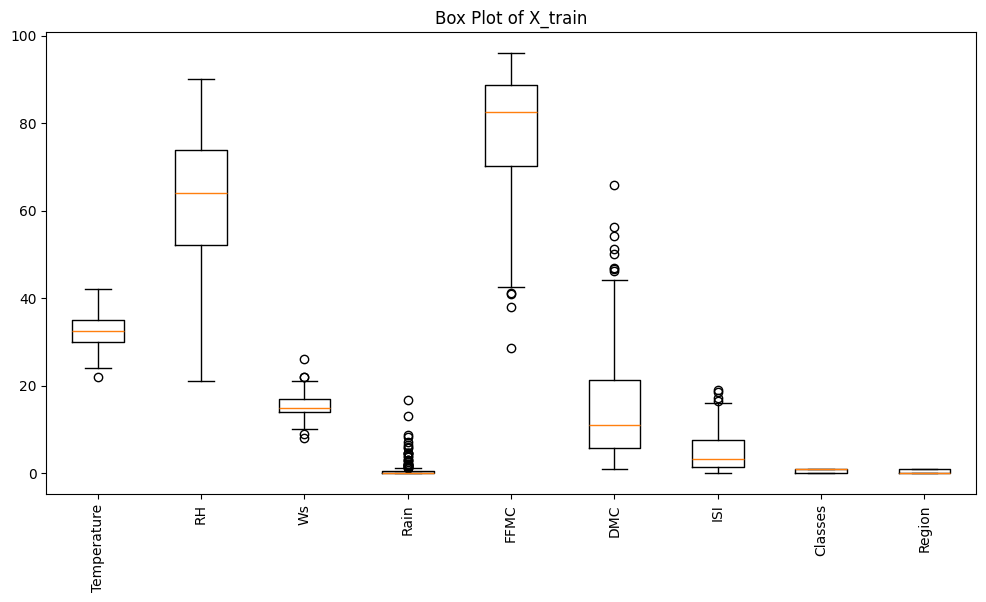

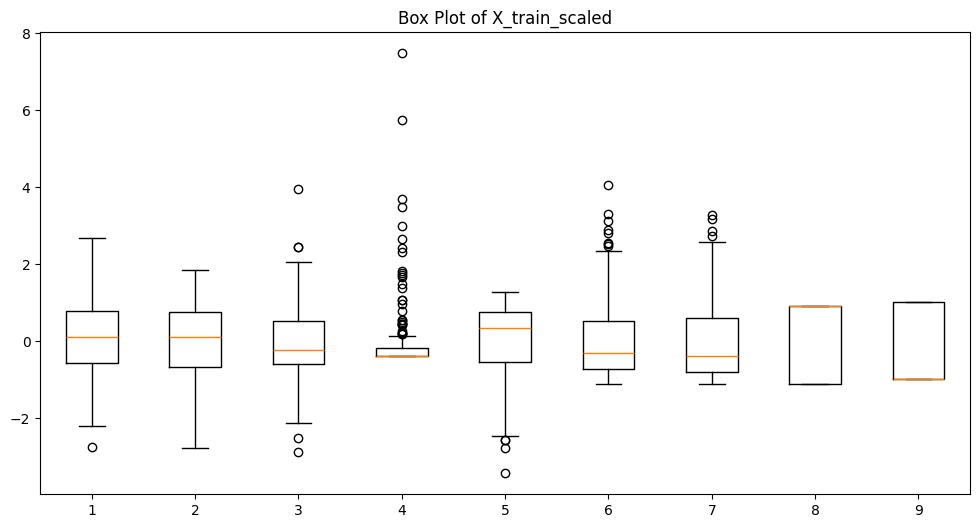

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.boxplot(xtrain)
plt.title("Box Plot of X_train")
plt.xticks(range(1,xtrain.shape[1] + 1), xtrain.columns, rotation=90)
plt.show()
plt.figure(figsize=(12,6))
plt.boxplot(xtrain_scaled)
plt.title("Box Plot of X_train_scaled")
plt.show()

Mean Squared Error: 0.6742766873791604
R^2 Score: 0.9847657384266951


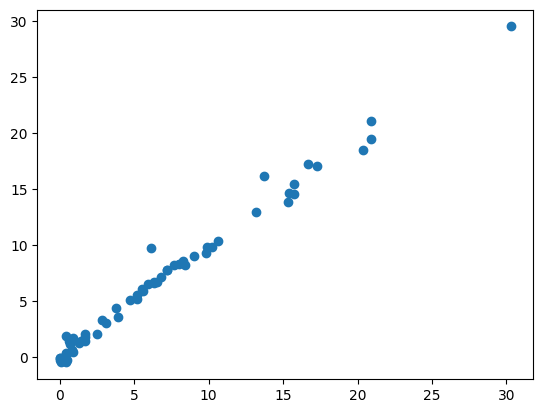

In [82]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
regression=LinearRegression()
regression.fit(xtrain_scaled,ytrain)
ypred=regression.predict(xtest_scaled)
print("Mean Squared Error:",mean_squared_error(ytest,ypred))
print("R^2 Score:",r2_score(ytest,ypred))
plt.scatter(ytest,ypred)

In [83]:
from sklearn.linear_model import Lasso

Mean Squared Error: 2.2483458918974764
R^2 Score: 0.9492020263112388


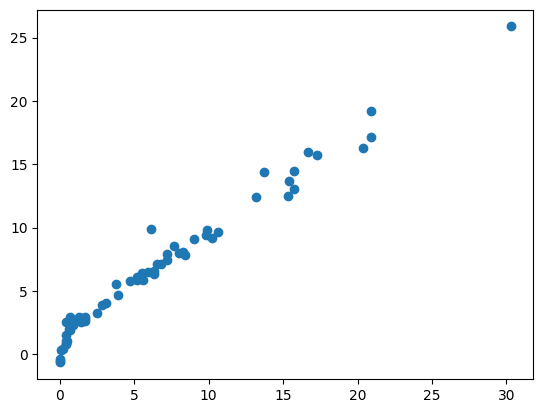

In [84]:
lasso=Lasso()
lasso.fit(xtrain_scaled,ytrain)
ypred=lasso.predict(xtest_scaled)
print("Mean Squared Error:",mean_squared_error(ytest,ypred))
print("R^2 Score:",r2_score(ytest,ypred))
plt.scatter(ytest,ypred)

Mean Squared Error: 0.6949198918152099
R^2 Score: 0.9842993364555512


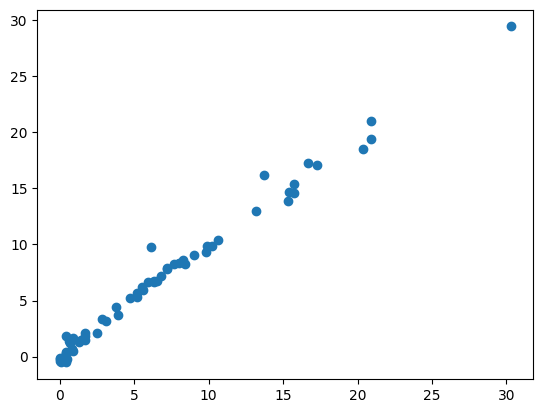

In [85]:
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(xtrain_scaled,ytrain)
ypred=ridge.predict(xtest_scaled)
print("Mean Squared Error:",mean_squared_error(ytest,ypred))
print("R^2 Score:",r2_score(ytest,ypred))
plt.scatter(ytest,ypred)

Mean Squared Error: 0.6949198918151434
R^2 Score: 0.9842993364555528


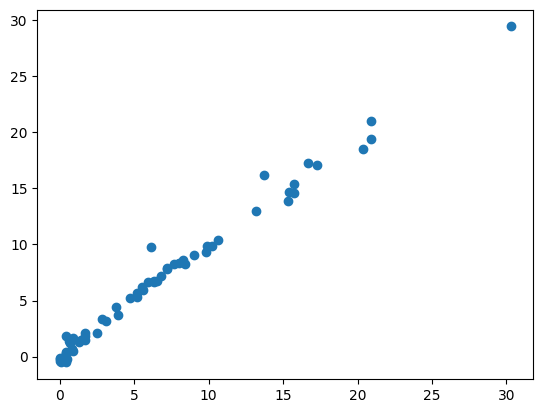

In [86]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV()
ridgecv.fit(xtrain_scaled,ytrain)
ypred=ridgecv.predict(xtest_scaled)
print("Mean Squared Error:",mean_squared_error(ytest,ypred))
print("R^2 Score:",r2_score(ytest,ypred))
plt.scatter(ytest,ypred)

In [88]:
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))